In [1]:
from torchvision import datasets
from torchvision.transforms import v2
import torch
from torch import nn
from torchvision import models
from sklearn import model_selection
import matplotlib.pyplot as plt
import utils
import metrics
import tqdm

plt.style.use('default')

In [2]:
COLORS = [
    "#FF0000",  # Red
    "#00FF00",  # Green
	"#0000FF",  # Blue
    "#FFFF00",  # Yellow
    "#FF00FF",  # Magenta
    "#00FFFF",  # Cyan
	"#FFA500",  # Orange
    "#B1636F",  # Purple
    "#BED944",
    "#9792D4FF",
]

SEED = 0

COLORED_PROPORTIONS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]	# Proportions of colored images in train and val images used for experimenting
TRAIN_BS = 32
VAL_BS = 32

In [3]:
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "mps"

In [4]:
train_dataset = datasets.MNIST(root="./data", download=True)
test_dataset = datasets.MNIST(root="./data", train=False, download=True)

In [5]:
print(train_dataset)
print(test_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test


In [6]:
train_transforms = v2.Compose(
	[
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
	]
)
test_transforms = v2.Compose(
	[
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
	]
)

### Display proportions before train/val split

Text(0.5, 1.0, 'Train Dataset Label Distribution before splitting')

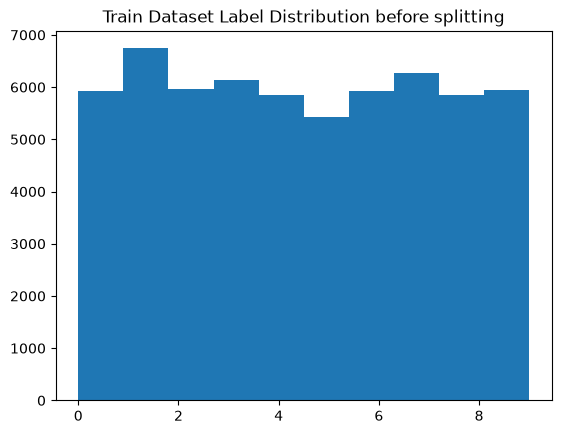

In [7]:
labels = torch.tensor([y for x, y in train_dataset])

plt.hist(labels, bins=10)
plt.title("Train Dataset Label Distribution before splitting")

In [8]:
train_split, val_split = model_selection.train_test_split(train_dataset, test_size=0.2, stratify=labels, random_state=SEED)

### Display proportions after train/val split

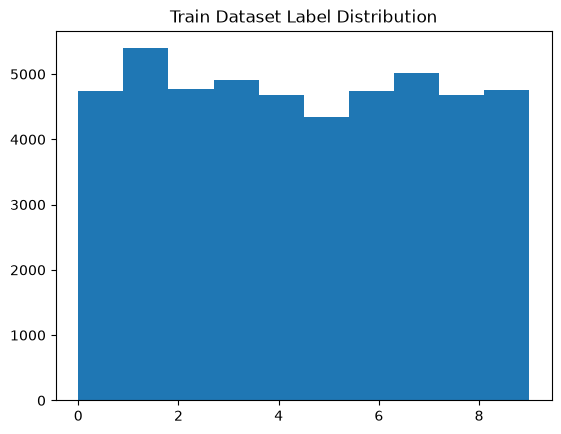

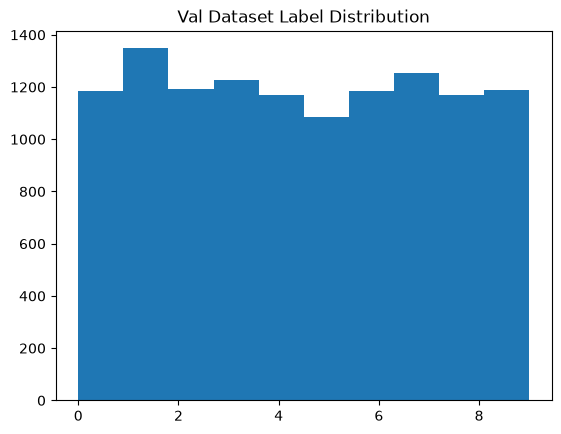

In [9]:
train_labels = torch.tensor([y for x, y in train_split])
val_labels = torch.tensor([y for x, y in val_split])

plt.hist(train_labels, bins=10)
plt.title("Train Dataset Label Distribution")
plt.show()

plt.hist(val_labels, bins=10)
plt.title("Val Dataset Label Distribution")
plt.show()

### Convert to torch dataset

In [10]:
class ColoredMNISTDataset(torch.utils.data.Dataset):
	"""Wrapper class that applies coloring based on the target class ID."""
	def __init__(self, dataset_list, transform=None, colored_proportions=0.95):
		"""
			Initialize 
		"""
		super().__init__()
		self.pil_to_tensor = v2.Compose(
			[
				v2.ToImage(),
				v2.ToDtype(torch.float32, scale=True)
			]
		)

		self.x = []
		for x, y in dataset_list:
			if torch.rand(1).item() < colored_proportions:
				colored_image = self._gray_to_colored(self.pil_to_tensor(x), y)
				self.x.append(colored_image)
			else:
				w, h = x.size
				self.x.append(self.pil_to_tensor(x).expand(1, 3, w, h))

		self.x = torch.cat(self.x, dim=0)
		self.y = torch.tensor([y for x, y in dataset_list])
		self.transform = transform

	def __len__(self):
		return len(self.x)
	
	def __getitem__(self, index):
		if self.transform is not None:
			return self.transform(self.x[index]), self.y[index]
		return self.x[index], self.y[index]
	
	def _gray_to_colored(self, x, y):
		assert len(COLORS) > y, f"Color index {y} is out of range for COLORS list."

		color = COLORS[y]
		colored_image = torch.zeros(3, x.shape[1], x.shape[2])
		colored_image[0] = x * int(color[1:3], 16) / 255.0
		colored_image[1] = x * int(color[3:5], 16) / 255.0
		colored_image[2] = x * int(color[5:7], 16) / 255.0
		return colored_image.unsqueeze(0)

In [11]:
class Model(nn.Module):
	def __init__(self, n_classes=10):
		super().__init__()
		self.fc = nn.Sequential(
			nn.Flatten(),
			nn.Linear(3*784, 2048),
			nn.Tanh(),
			nn.Linear(2048, 512),
			nn.Tanh(),
			nn.Linear(512, 64),
			nn.Tanh(),
			nn.Linear(64, n_classes)
		)

	def forward(self, x):
		return self.fc(x)		

In [17]:
def train_one_epoch(model, train_dl, criterion, optimizer, metrics_calculator, device="cuda"):
	"""
	Performs the optimization over the whole dataset once.
	Resets the metrics_calculator at the beggining and updates metrics inplace but does not return the metrics directly.
	Those can be accesed outside of this function.

	Args:
		model: Model trained.
		train_dl: Dataloader with data used for training.
		criterion: Criterion used for calculating the loss.
		optimizer: Optimizer used for updating model's weights.
		metrics_calculator: Instance of metrics calculator used for computing metrics on train dataset.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		float: Mean training loss for current epoch.
	"""

	metrics_calculator.reset()
	model.train()
	train_epoch_loss = 0
	n_instances = 0
	
	for inputs, targets in tqdm.tqdm(train_dl, desc="Training"):
		optimizer.zero_grad()

		inputs = inputs.to(device)
		targets = targets.to(device)

		outputs = model(inputs)

		loss = criterion(outputs, targets)
		loss.backward()
		optimizer.step()

		train_epoch_loss += loss.item()
		metrics_calculator.update(outputs.detach(), targets.detach())
		n_instances += inputs.shape[0]
	
	mean_epoch_loss = train_epoch_loss / n_instances
	return mean_epoch_loss

@torch.no_grad()
def evaluate(model, dataloader, criterion, metrics_calculator, device="cuda"):
	"""
	Evaluates the model given a dataloader

	Args:
		model: Model to evaluate.
		dataloader: Dataloader with data used for training.
		criterion: Criterion used for calculating the loss.
		metrics_calculator: Instance of metrics calculator used for computing metrics.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		float: Mean loss.
	"""

	metrics_calculator.reset()
	model.eval()
	total_loss = 0
	n_instances = 0
	
	for inputs, targets in tqdm.tqdm(dataloader, desc="Evaluating"):
		inputs = inputs.to(device)
		targets = targets.to(device)

		outputs = model(inputs)

		loss = criterion(outputs, targets)

		total_loss += loss.item()
		metrics_calculator.update(outputs.detach(), targets.detach())
		n_instances += inputs.shape[0]
	
	mean_loss = total_loss / n_instances
	return mean_loss


def train(model, train_dl, val_dl, criterion, optimizer, metrics_calculator, epochs=10, device="cuda"):
	"""
	Trains the model for the specified number of epochs.

	Args:
		model: Model trained.
		train_dl: Dataloader with training data.
		val_dl: Dataloader with validation data.
		criterion: Criterion used for calculating the loss.
		optimizer: Optimizer used to update model parameters.
		metrics_calculator: Instance of metrics calculator used for computing metrics.
		epochs: Number of epochs to train the model for.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		list[float]: List of training loss in each epoch.
		list[float]: List of validation loss in each epoch.
	"""
	best_weights = model.state_dict()
	best_val_loss = float("inf")
	train_losses = []
	val_losses = []

	for epoch in range(epochs):
		train_loss = train_one_epoch(model, train_dl, criterion, optimizer, metrics_calculator, device)
		accuracy, precision, recall, f1_score, auprc, auroc = metrics_calculator.compute_all()
		val_loss = evaluate(model, val_dl, criterion, metrics_calculator, device)
		accuracy, precision, recall, f1_score, auprc, auroc = metrics_calculator.compute_all()

		print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1_score:.4f}, AUPRC: {auprc:.4f}, AUROC: {auroc:.4f}")

		train_losses.append(train_loss)
		val_losses.append(val_loss)

		if val_loss < best_val_loss:
			best_val_loss = val_loss
			best_weights = model.state_dict()

	model.load_state_dict(best_weights)

	return train_losses, val_losses

Proportion of colored images: 0.5


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 244.74it/s]


Epoch 1/10 - Train Loss: 0.0068, Val Loss: 0.0038, Accuracy: 0.9637, Precision: 0.9637, Recall: 0.9637, F1 Score: 0.9637, AUPRC: 0.9895, AUROC: 0.9974


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 241.76it/s]


Epoch 2/10 - Train Loss: 0.0036, Val Loss: 0.0033, Accuracy: 0.9687, Precision: 0.9687, Recall: 0.9687, F1 Score: 0.9687, AUPRC: 0.9911, AUROC: 0.9976


...

Epoch 8/10 - Train Loss: 0.0020, Val Loss: 0.0026, Accuracy: 0.9742, Precision: 0.9742, Recall: 0.9742, F1 Score: 0.9742, AUPRC: 0.9929, AUROC: 0.9982


Evaluating: 100%|██████████| 375/375 [00:02<00:00, 185.11it/s]


Epoch 9/10 - Train Loss: 0.0019, Val Loss: 0.0025, Accuracy: 0.9746, Precision: 0.9746, Recall: 0.9746, F1 Score: 0.9746, AUPRC: 0.9920, AUROC: 0.9981


Evaluating: 100%|██████████| 375/375 [00:02<00:00, 172.74it/s]


Epoch 10/10 - Train Loss: 0.0019, Val Loss: 0.0031, Accuracy: 0.9686, Precision: 0.9686, Recall: 0.9686, F1 Score: 0.9686, AUPRC: 0.9907, AUROC: 0.9979


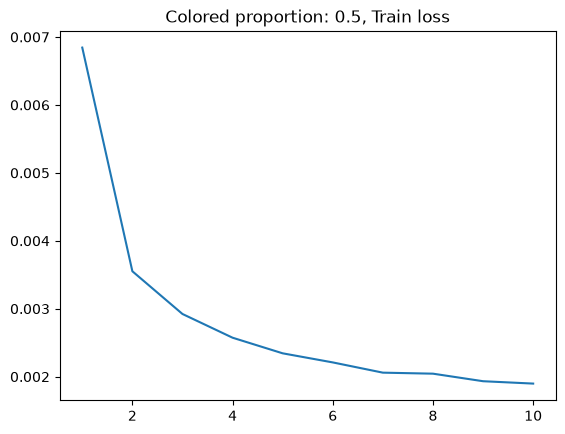

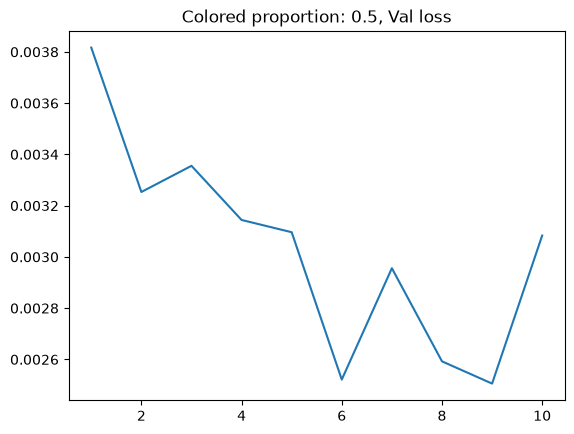

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 219.09it/s]


Performance on clean validation set:
Clean Val Loss: 0.0060, Accuracy: 0.9433, Precision: 0.9433, Recall: 0.9433, F1 Score: 0.9433, AUPRC: 0.9781, AUROC: 0.9952
Performance on fully colored validation set:
Colored Val Loss: 0.0005, Accuracy: 0.9947, Precision: 0.9947, Recall: 0.9947, F1 Score: 0.9947, AUPRC: 0.9993, AUROC: 0.9998
Proportion of colored images: 0.6


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 240.31it/s]


Epoch 1/10 - Train Loss: 0.0060, Val Loss: 0.0030, Accuracy: 0.9726, Precision: 0.9726, Recall: 0.9726, F1 Score: 0.9726, AUPRC: 0.9928, AUROC: 0.9979


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 244.02it/s]


...

Epoch 8/10 - Train Loss: 0.0016, Val Loss: 0.0025, Accuracy: 0.9773, Precision: 0.9773, Recall: 0.9773, F1 Score: 0.9773, AUPRC: 0.9928, AUROC: 0.9981


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 244.24it/s]


Epoch 9/10 - Train Loss: 0.0016, Val Loss: 0.0024, Accuracy: 0.9767, Precision: 0.9767, Recall: 0.9767, F1 Score: 0.9767, AUPRC: 0.9927, AUROC: 0.9981


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 245.20it/s]

Epoch 10/10 - Train Loss: 0.0014, Val Loss: 0.0026, Accuracy: 0.9769, Precision: 0.9769, Recall: 0.9769, F1 Score: 0.9769, AUPRC: 0.9929, AUROC: 0.9981


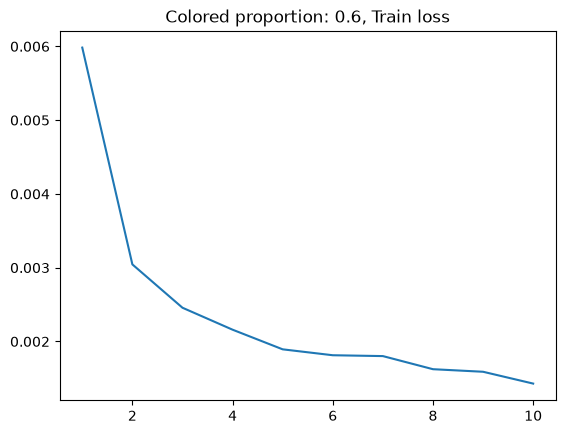

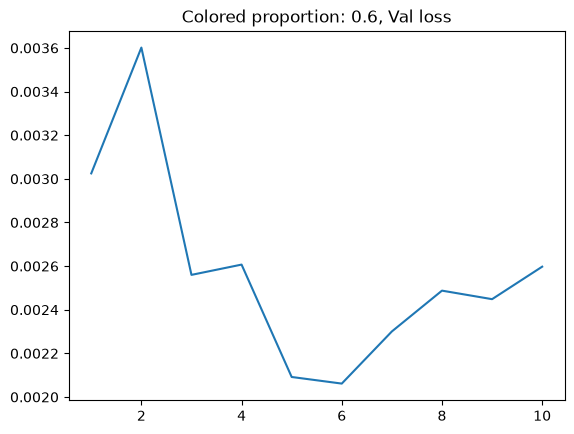

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 248.05it/s]


Performance on clean validation set:
Clean Val Loss: 0.0061, Accuracy: 0.9457, Precision: 0.9457, Recall: 0.9457, F1 Score: 0.9457, AUPRC: 0.9786, AUROC: 0.9951
Performance on fully colored validation set:
Colored Val Loss: 0.0002, Accuracy: 0.9977, Precision: 0.9977, Recall: 0.9977, F1 Score: 0.9977, AUPRC: 0.9997, AUROC: 0.9999
Proportion of colored images: 0.7


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 244.23it/s]


Epoch 1/10 - Train Loss: 0.0053, Val Loss: 0.0031, Accuracy: 0.9714, Precision: 0.9714, Recall: 0.9714, F1 Score: 0.9714, AUPRC: 0.9920, AUROC: 0.9975


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 241.00it/s]


...

Epoch 8/10 - Train Loss: 0.0016, Val Loss: 0.0022, Accuracy: 0.9799, Precision: 0.9799, Recall: 0.9799, F1 Score: 0.9799, AUPRC: 0.9925, AUROC: 0.9981


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 243.88it/s]


Epoch 9/10 - Train Loss: 0.0014, Val Loss: 0.0022, Accuracy: 0.9797, Precision: 0.9797, Recall: 0.9797, F1 Score: 0.9797, AUPRC: 0.9916, AUROC: 0.9977


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 238.31it/s]

Epoch 10/10 - Train Loss: 0.0013, Val Loss: 0.0024, Accuracy: 0.9801, Precision: 0.9801, Recall: 0.9801, F1 Score: 0.9801, AUPRC: 0.9917, AUROC: 0.9976


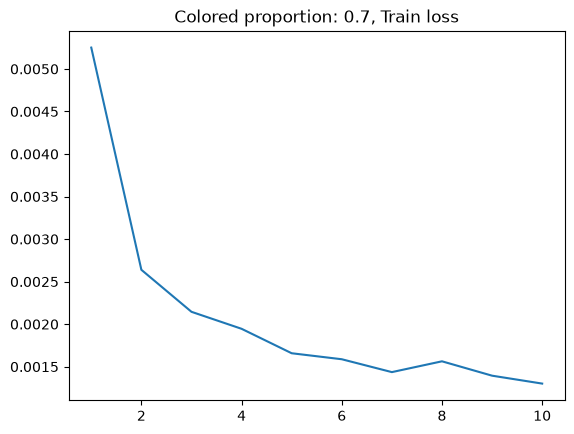

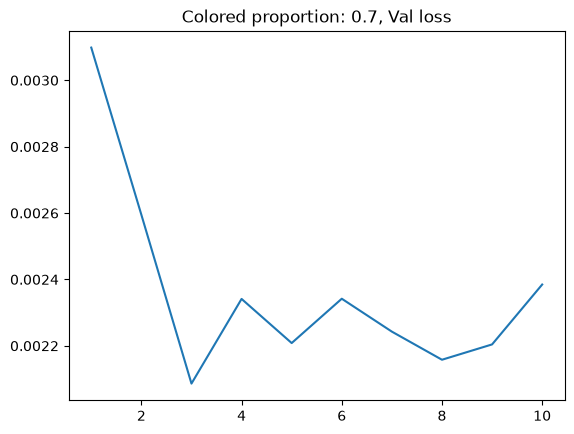

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 242.12it/s]


Performance on clean validation set:
Clean Val Loss: 0.0066, Accuracy: 0.9429, Precision: 0.9429, Recall: 0.9429, F1 Score: 0.9429, AUPRC: 0.9737, AUROC: 0.9934
Performance on fully colored validation set:
Colored Val Loss: 0.0002, Accuracy: 0.9987, Precision: 0.9987, Recall: 0.9987, F1 Score: 0.9987, AUPRC: 0.9998, AUROC: 0.9999
Proportion of colored images: 0.8


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 241.97it/s]


Epoch 1/10 - Train Loss: 0.0043, Val Loss: 0.0025, Accuracy: 0.9780, Precision: 0.9780, Recall: 0.9780, F1 Score: 0.9780, AUPRC: 0.9948, AUROC: 0.9982


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 241.96it/s]


...

Epoch 8/10 - Train Loss: 0.0012, Val Loss: 0.0014, Accuracy: 0.9872, Precision: 0.9872, Recall: 0.9872, F1 Score: 0.9872, AUPRC: 0.9965, AUROC: 0.9989


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 242.92it/s]


Epoch 9/10 - Train Loss: 0.0010, Val Loss: 0.0014, Accuracy: 0.9867, Precision: 0.9867, Recall: 0.9867, F1 Score: 0.9867, AUPRC: 0.9946, AUROC: 0.9985


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 242.54it/s]

Epoch 10/10 - Train Loss: 0.0011, Val Loss: 0.0015, Accuracy: 0.9862, Precision: 0.9862, Recall: 0.9862, F1 Score: 0.9862, AUPRC: 0.9958, AUROC: 0.9989


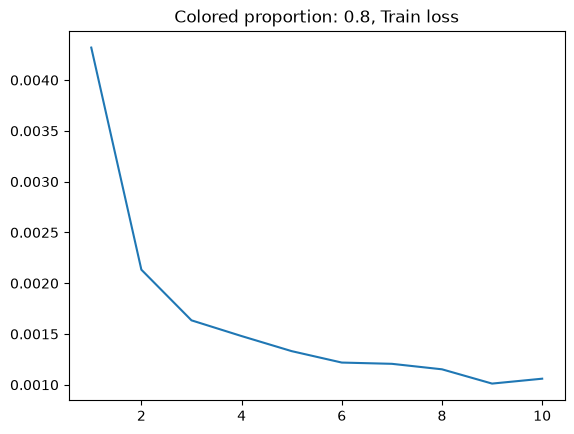

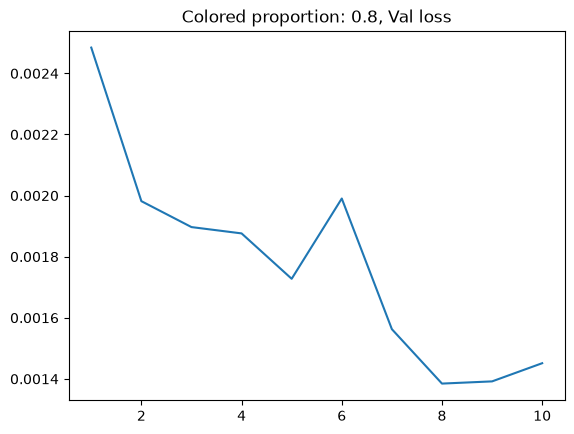

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 244.17it/s]


Performance on clean validation set:
Clean Val Loss: 0.0068, Accuracy: 0.9369, Precision: 0.9369, Recall: 0.9369, F1 Score: 0.9369, AUPRC: 0.9680, AUROC: 0.9928
Performance on fully colored validation set:
Colored Val Loss: 0.0002, Accuracy: 0.9983, Precision: 0.9983, Recall: 0.9983, F1 Score: 0.9983, AUPRC: 0.9998, AUROC: 1.0000
Proportion of colored images: 0.9


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 245.71it/s]


Epoch 1/10 - Train Loss: 0.0032, Val Loss: 0.0015, Accuracy: 0.9858, Precision: 0.9858, Recall: 0.9858, F1 Score: 0.9858, AUPRC: 0.9974, AUROC: 0.9992


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 237.11it/s]


...

Epoch 8/10 - Train Loss: 0.0008, Val Loss: 0.0010, Accuracy: 0.9902, Precision: 0.9902, Recall: 0.9902, F1 Score: 0.9902, AUPRC: 0.9958, AUROC: 0.9989


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 241.51it/s]


Epoch 9/10 - Train Loss: 0.0008, Val Loss: 0.0010, Accuracy: 0.9902, Precision: 0.9902, Recall: 0.9902, F1 Score: 0.9902, AUPRC: 0.9971, AUROC: 0.9992


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 243.75it/s]

Epoch 10/10 - Train Loss: 0.0007, Val Loss: 0.0012, Accuracy: 0.9887, Precision: 0.9887, Recall: 0.9887, F1 Score: 0.9887, AUPRC: 0.9964, AUROC: 0.9989


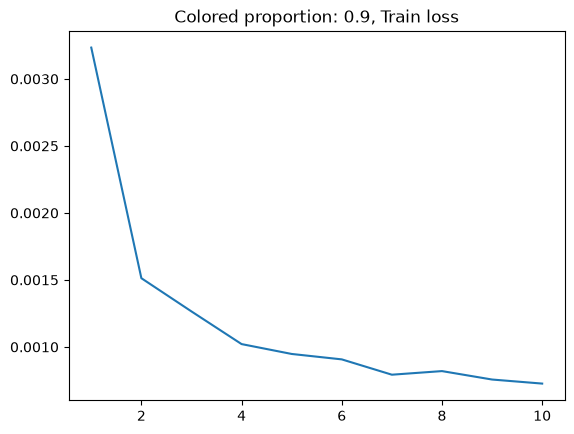

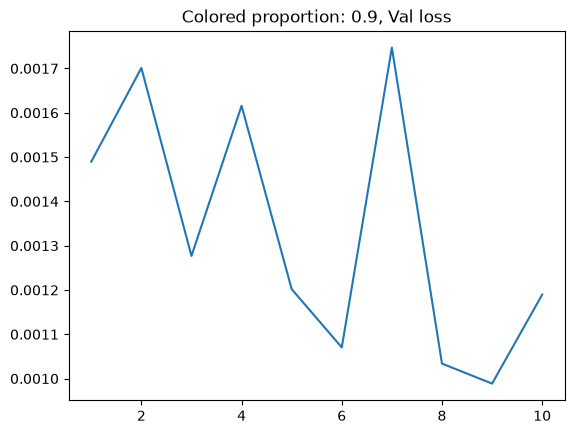

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 244.62it/s]


Performance on clean validation set:
Clean Val Loss: 0.0102, Accuracy: 0.9038, Precision: 0.9038, Recall: 0.9038, F1 Score: 0.9038, AUPRC: 0.9410, AUROC: 0.9875
Performance on fully colored validation set:
Colored Val Loss: 0.0001, Accuracy: 0.9995, Precision: 0.9995, Recall: 0.9995, F1 Score: 0.9995, AUPRC: 0.9999, AUROC: 1.0000
Proportion of colored images: 0.95


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 242.30it/s]


Epoch 1/10 - Train Loss: 0.0024, Val Loss: 0.0011, Accuracy: 0.9912, Precision: 0.9912, Recall: 0.9912, F1 Score: 0.9912, AUPRC: 0.9981, AUROC: 0.9992


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 242.91it/s]


...

Epoch 8/10 - Train Loss: 0.0005, Val Loss: 0.0008, Accuracy: 0.9930, Precision: 0.9930, Recall: 0.9930, F1 Score: 0.9930, AUPRC: 0.9972, AUROC: 0.9992


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 243.91it/s]


Epoch 9/10 - Train Loss: 0.0005, Val Loss: 0.0009, Accuracy: 0.9918, Precision: 0.9918, Recall: 0.9918, F1 Score: 0.9918, AUPRC: 0.9971, AUROC: 0.9991


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 245.10it/s]

Epoch 10/10 - Train Loss: 0.0004, Val Loss: 0.0008, Accuracy: 0.9930, Precision: 0.9930, Recall: 0.9930, F1 Score: 0.9930, AUPRC: 0.9974, AUROC: 0.9991


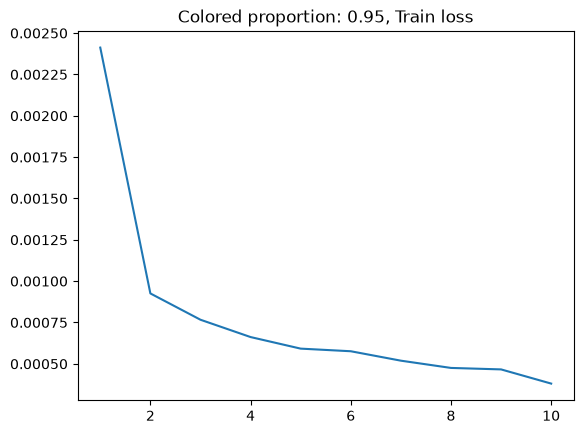

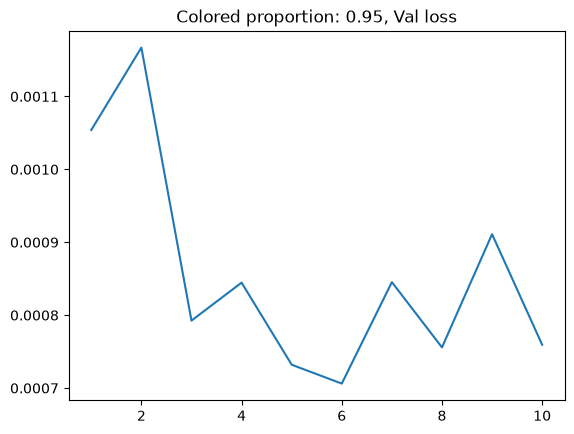

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 242.84it/s]


Performance on clean validation set:
Clean Val Loss: 0.0128, Accuracy: 0.8791, Precision: 0.8791, Recall: 0.8791, F1 Score: 0.8791, AUPRC: 0.9274, AUROC: 0.9835
Performance on fully colored validation set:
Colored Val Loss: 0.0001, Accuracy: 0.9994, Precision: 0.9994, Recall: 0.9994, F1 Score: 0.9994, AUPRC: 0.9999, AUROC: 1.0000
Proportion of colored images: 1.0


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 249.05it/s]


Epoch 1/10 - Train Loss: 0.0009, Val Loss: 0.0001, Accuracy: 0.9993, Precision: 0.9993, Recall: 0.9993, F1 Score: 0.9993, AUPRC: 1.0000, AUROC: 1.0000


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 237.89it/s]


...

Epoch 8/10 - Train Loss: 0.0000, Val Loss: 0.0000, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000, AUPRC: 1.0000, AUROC: 1.0000


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 243.52it/s]


Epoch 9/10 - Train Loss: 0.0000, Val Loss: 0.0000, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000, AUPRC: 1.0000, AUROC: 1.0000


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 225.76it/s]


Epoch 10/10 - Train Loss: 0.0000, Val Loss: 0.0000, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000, AUPRC: 1.0000, AUROC: 1.0000


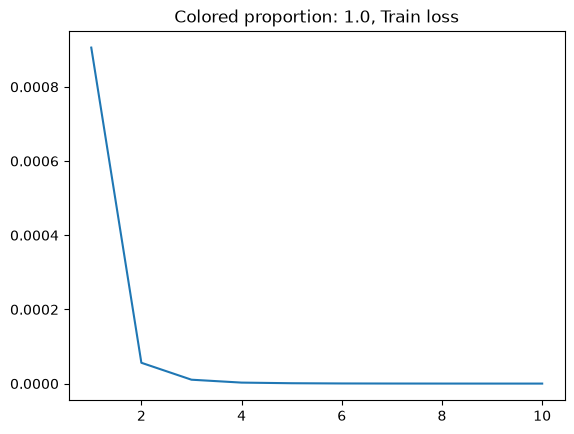

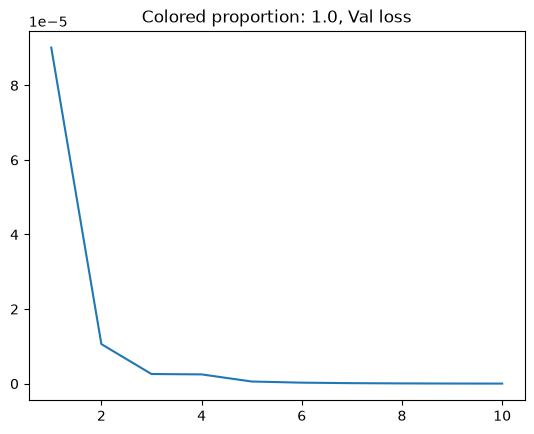

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 246.63it/s]


Performance on clean validation set:
Clean Val Loss: 0.4270, Accuracy: 0.1018, Precision: 0.1018, Recall: 0.1018, F1 Score: 0.1017, AUPRC: 0.2619, AUROC: 0.7334
Performance on fully colored validation set:
Colored Val Loss: 0.0000, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000, AUPRC: 1.0000, AUROC: 1.0000


In [18]:
metrics_calculator = metrics.MetricsCalculator(num_classes=len(train_labels.unique()))

model_weights = [] # Best weights for each colored proportion

for proportion in COLORED_PROPORTIONS:
	print(f"Proportion of colored images: {proportion}")
	metrics_calculator.reset()
	
	train_dataset = ColoredMNISTDataset(train_split, colored_proportions=proportion)
	val_dataset = ColoredMNISTDataset(val_split, colored_proportions=proportion)
	clean_val_dataset = ColoredMNISTDataset(val_split, colored_proportions=0)
	colored_val_dataset = ColoredMNISTDataset(val_split, colored_proportions=1)

	train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=TRAIN_BS, shuffle=True)
	val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=VAL_BS)
	clean_val_dataloader = torch.utils.data.DataLoader(clean_val_dataset, batch_size=VAL_BS)
	colored_val_dataloader = torch.utils.data.DataLoader(colored_val_dataset, batch_size=VAL_BS)

	model = Model()
	model.to(device)

	optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
	criterion = nn.CrossEntropyLoss()

	# Train the model
	train_losses, val_losses = train(model, train_dataloader, val_dataloader, criterion, optimizer, metrics_calculator, device=device)

	# Save model weights in list to reuse later
	model_weights.append(model.state_dict())
	
	# Plot results
	utils.plot_loss(train_losses, f"Colored proportion: {proportion}, Train loss")
	utils.plot_loss(val_losses, f"Colored proportion: {proportion}, Val loss")

	# Evaluate the model on clean validation dataset
	clean_val_loss = evaluate(model, clean_val_dataloader, criterion, metrics_calculator, device)
	clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

	# Evaluate the model on fully colored validation dataset
	colored_val_loss = evaluate(model, colored_val_dataloader, criterion, metrics_calculator, device)
	colored_val_accuracy, colored_val_precision, colored_val_recall, colored_val_f1_score, colored_val_auprc, colored_val_auroc = metrics_calculator.compute_all()

	print("Performance on clean validation set:")
	print(f"Clean Val Loss: {clean_val_loss:.4f}, Accuracy: {clean_val_accuracy:.4f}, Precision: {clean_val_precision:.4f}, Recall: {clean_val_recall:.4f}, F1 Score: {clean_val_f1_score:.4f}, AUPRC: {clean_val_auprc:.4f}, AUROC: {clean_val_auroc:.4f}")
	print("Performance on fully colored validation set:")
	print(f"Colored Val Loss: {colored_val_loss:.4f}, Accuracy: {colored_val_accuracy:.4f}, Precision: {colored_val_precision:.4f}, Recall: {colored_val_recall:.4f}, F1 Score: {colored_val_f1_score:.4f}, AUPRC: {colored_val_auprc:.4f}, AUROC: {colored_val_auroc:.4f}")
